# Music Genre Classification Capstone Project

In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, RandomFlip, RandomZoom, RandomContrast
from keras.applications import VGG16
from keras.optimizers import Adam
import librosa

In [ ]:
# styled_stats(y_true, y_pred, le, title=...) is defined in the Model section below

In [ ]:
RANDOM_STATE = 42   # For reproducibility

## Data

In [ ]:
data = pd.read_csv('data/features_3_sec.csv')

In [17]:
# --- Missing Values ---
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print("=== Missing Values ===")
if missing_df.empty:
    print("No missing values found across all columns.")
else:
    print(missing_df.to_string())

# --- Class Imbalance ---
class_counts = data['label'].value_counts().sort_values(ascending=False)
class_pct = (class_counts / len(data) * 100).round(2)
imbalance_df = pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_pct})

print("\n=== Class Distribution ===")
print(imbalance_df.to_string())

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}")

if imbalance_ratio < 1.5:
    print("Dataset is well balanced — no resampling likely needed.")
elif imbalance_ratio < 3:
    print("Dataset has mild imbalance — monitor per-class metrics (precision/recall).")
else:
    print("Dataset has significant imbalance — consider oversampling (SMOTE) or class weights.")

=== Missing Values ===
No missing values found across all columns.

=== Class Distribution ===
           Count  Percentage (%)
label                           
blues       1000           10.01
jazz        1000           10.01
metal       1000           10.01
pop         1000           10.01
reggae      1000           10.01
disco        999           10.00
classical    998            9.99
hiphop       998            9.99
rock         998            9.99
country      997            9.98

Imbalance ratio (max/min): 1.00
Dataset is well balanced — no resampling likely needed.


In [18]:
le = LabelEncoder()

X = data.drop(columns=['filename', 'length', 'label'])
y = le.fit_transform(data['label'])

X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state=RANDOM_STATE)

## Model

In [38]:
from IPython.display import display

def styled_stats(y_true, y_pred, le, title="Confusion Matrix"):
    """Display classification report (DataFrame with inverse labels) and minimal dark confusion matrix."""
    report = classification_report(y_true, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).T
    idx_map = {str(i): le.classes_[i] for i in range(len(le.classes_))}
    df_report = df_report.rename(index=idx_map)
    display(df_report)
    cmap_cm = LinearSegmentedColormap.from_list(
        'dark_cm', ['#2a2a2a', '#1e3a5f', '#3d6cb9', '#6b9bd1'], N=256
    )
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(10, 8), facecolor='#1a1a1a')
    ax.set_facecolor('#1a1a1a')
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=le.classes_, ax=ax,
        cmap=cmap_cm, colorbar=False
    )
    ax.set_title(f"Confusion Matrix — {title}", fontsize=14, color='#e0e0e0')
    ax.set_xlabel('Predicted', color='#b0b0b0')
    ax.set_ylabel('True', color='#b0b0b0')
    ax.tick_params(colors='#b0b0b0')
    for spine in ax.spines.values():
        spine.set_color('#404040')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Standard Models
Here we test basic Support Vector Machine, RandomForestClassifier, Logistic Regression, and K-Nearest Neighbors models.

In [52]:
standard_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC()) # Placeholder
])

standard_models = [
    {
        'clf': [SVC()],
        'clf__kernel': ['rbf'],
        'clf__C': [15]
    },
    {
        'clf': [RandomForestClassifier()],
        'clf__n_estimators': [100],
        'clf__max_depth': [20]
    },
    {
        'clf': [KNeighborsClassifier()],
        'clf__n_neighbors': [5],
    },
    {
        'clf': [LogisticRegression()],
        'clf__solver': ['lbfgs'],
        'clf__max_iter': [1000],
        'clf__C': [1.0],
    },
]

grid = GridSearchCV(standard_pipe, standard_models, cv=5, refit=True, return_train_score=True, verbose=2)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END ..............clf=SVC(), clf__C=15, clf__kernel=rbf; total time=   0.6s
[CV] END ..............clf=SVC(), clf__C=15, clf__kernel=rbf; total time=   0.6s
[CV] END ..............clf=SVC(), clf__C=15, clf__kernel=rbf; total time=   0.6s
[CV] END ..............clf=SVC(), clf__C=15, clf__kernel=rbf; total time=   0.6s
[CV] END ..............clf=SVC(), clf__C=15, clf__kernel=rbf; total time=   0.6s
[CV] END clf=RandomForestClassifier(), clf__max_depth=20, clf__n_estimators=100; total time=   1.9s
[CV] END clf=RandomForestClassifier(), clf__max_depth=20, clf__n_estimators=100; total time=   1.9s
[CV] END clf=RandomForestClassifier(), clf__max_depth=20, clf__n_estimators=100; total time=   1.9s
[CV] END clf=RandomForestClassifier(), clf__max_depth=20, clf__n_estimators=100; total time=   1.8s
[CV] END clf=RandomForestClassifier(), clf__max_depth=20, clf__n_estimators=100; total time=   1.8s
[CV] END .....clf=KNeighborsClassif

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...clf', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'clf': [SVC()], 'clf__C': [15], 'clf__kernel': ['rbf']}, {'clf': [RandomForestClassifier()], 'clf__max_depth': [20], 'clf__n_estimators': [100]}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

Best Classifier : SVC
Validation Accuracy: 92.19%



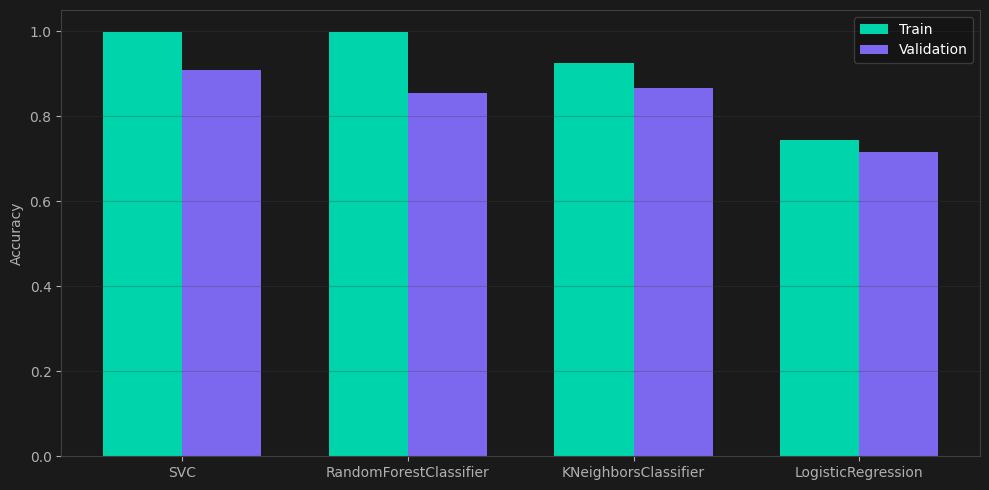

In [53]:
## Best Model Summary
best_clf_name = type(grid.best_estimator_.named_steps['clf']).__name__
print(f"Best Classifier : {best_clf_name}")
print(f"Validation Accuracy: {grid.score(X_val, y_val):.2%}\n")

# Train vs validation accuracy per candidate (dark theme)
res = pd.DataFrame(grid.cv_results_)
labels = [type(p['clf']).__name__ for p in res['params']]
x = np.arange(len(labels))
width = 0.35

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 5), facecolor='#1a1a1a')
ax.set_facecolor('#1a1a1a')
bars1 = ax.bar(x - width/2, res['mean_train_score'], width, label='Train', color='#00d4aa')
bars2 = ax.bar(x + width/2, res['mean_test_score'], width, label='Validation', color='#7b68ee')
ax.set_ylabel('Accuracy', color='#b0b0b0')
ax.set_xticks(x)
ax.set_xticklabels(labels, color='#b0b0b0')
ax.tick_params(colors='#b0b0b0')
ax.legend(framealpha=0.2)
ax.grid(True, alpha=0.3, color='#404040', axis='y')
ax.spines[:].set_color('#404040')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

,precision,recall,f1-score,support
blues,0.906780,0.972727,0.938596,110.000000
classical,0.877358,0.978947,0.925373,95.000000
country,0.857143,0.866667,0.861878,90.000000
disco,0.917526,0.890000,0.903553,100.000000
hiphop,0.938053,0.954955,0.946429,111.000000
jazz,0.928571,0.928571,0.928571,98.000000
metal,0.960000,0.969697,0.964824,99.000000
pop,0.943182,0.943182,0.943182,88.000000
reggae,0.951456,0.915888,0.933333,107.000000
rock,0.941176,0.792079,0.860215,101.000000


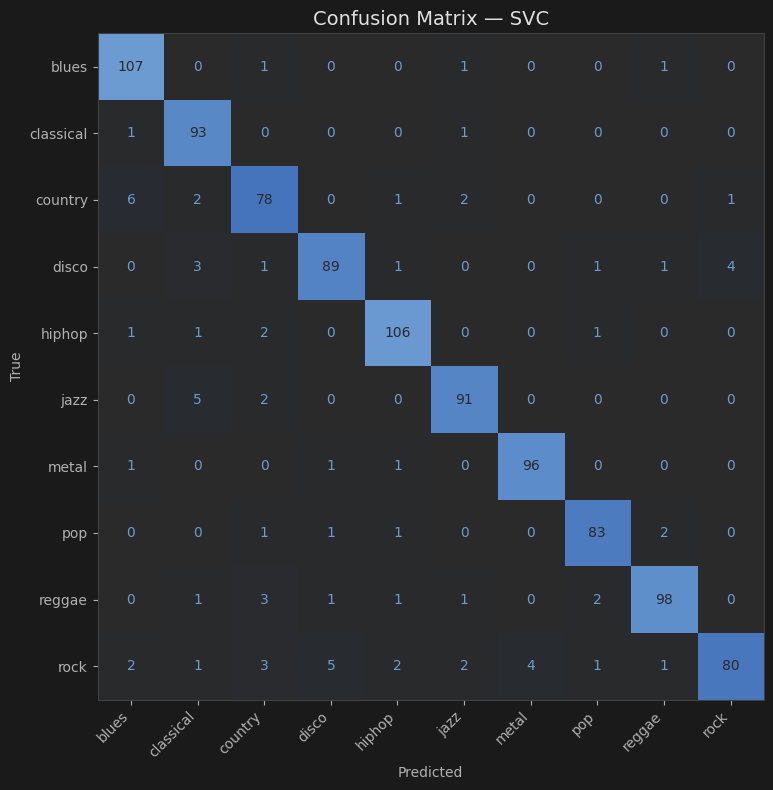

In [54]:
## Classification Report and Confusion Matrix
standard_y_pred = grid.predict(X_val)
styled_stats(y_val, standard_y_pred, le, title=best_clf_name)

### Neural Network
Here we test a dense MLP.

In [21]:
# Sklearn pipelines scale internally — Keras models do not.
# Fit scaler on training data only, then apply to val/test to avoid data leakage.
# CNN images are already normalized to [0, 1] during loading and need no further scaling.
mlp_scaler = StandardScaler()
X_train_scaled = mlp_scaler.fit_transform(X_train)
X_val_scaled   = mlp_scaler.transform(X_val)
X_test_scaled  = mlp_scaler.transform(X_test)

In [22]:
N_FEATURES = X_train.shape[1]   # 57
N_CLASSES  = len(np.unique(y))  # 10

# ── MLP ───────────────────────────────────────────────────────────────────────
mlp = Sequential([
    Dense(256, activation='relu', input_shape=(N_FEATURES,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(N_CLASSES, activation='softmax'),
], name='mlp')

mlp.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

mlp.summary()

/Users/kbi102003/Documents/GitHub/KBI-Capstone-Project/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │        14,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,186 (227.29 KB)

 Trainable params: 57,418 (224.29 KB)

 Non-trainable params: 768 (3.00 KB)

In [23]:
mlp_history = mlp.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=2
)

Epoch 1/100
250/250 - 1s - 4ms/step - accuracy: 0.4341 - loss: 1.6448 - val_accuracy: 0.6476 - val_loss: 1.0664
Epoch 2/100
250/250 - 0s - 615us/step - accuracy: 0.5831 - loss: 1.1880 - val_accuracy: 0.7237 - val_loss: 0.8372
Epoch 3/100
250/250 - 0s - 616us/step - accuracy: 0.6463 - loss: 1.0183 - val_accuracy: 0.7367 - val_loss: 0.7691
Epoch 4/100
250/250 - 0s - 612us/step - accuracy: 0.6817 - loss: 0.9235 - val_accuracy: 0.7477 - val_loss: 0.7220
Epoch 5/100
250/250 - 0s - 609us/step - accuracy: 0.6937 - loss: 0.8723 - val_accuracy: 0.7748 - val_loss: 0.6751
Epoch 6/100
250/250 - 0s - 611us/step - accuracy: 0.7180 - loss: 0.8128 - val_accuracy: 0.7828 - val_loss: 0.6324
Epoch 7/100
250/250 - 0s - 608us/step - accuracy: 0.7380 - loss: 0.7645 - val_accuracy: 0.7948 - val_loss: 0.6189
Epoch 8/100
250/250 - 0s - 610us/step - accuracy: 0.7508 - loss: 0.7151 - val_accuracy: 0.7878 - val_loss: 0.5969
Epoch 9/100
250/250 - 0s - 605us/step - accuracy: 0.7605 - loss: 0.7023 - val_accuracy: 0.

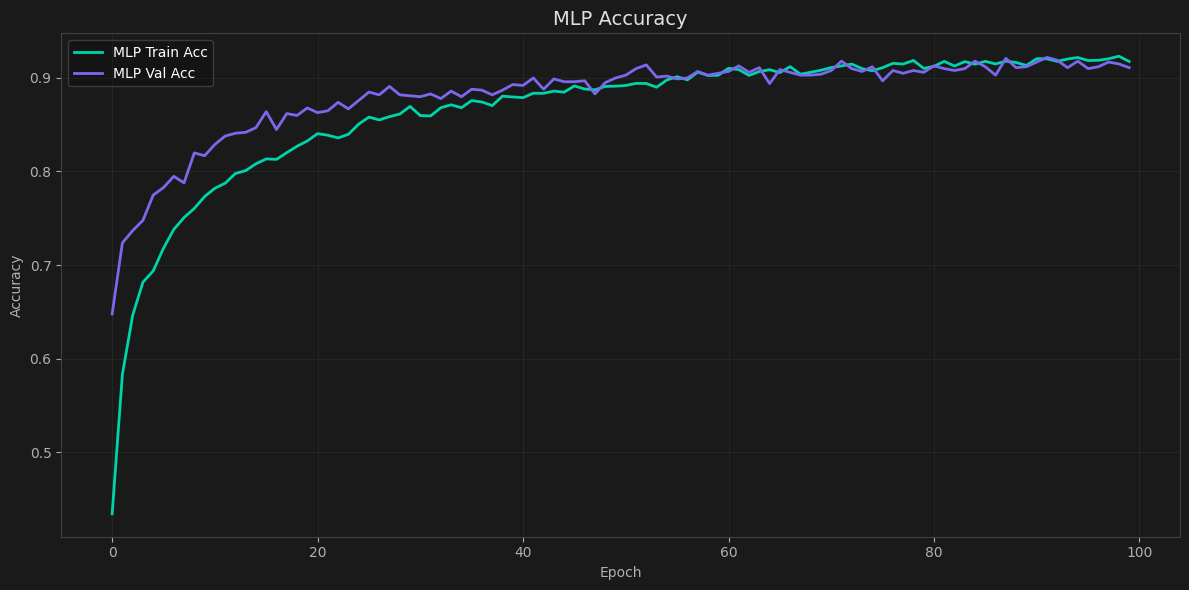

In [24]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 6), facecolor='#1a1a1a')
ax.set_facecolor('#1a1a1a')
ax.plot(mlp_history.history['accuracy'], label='MLP Train Acc', color='#00d4aa', linewidth=2)
ax.plot(mlp_history.history['val_accuracy'], label='MLP Val Acc', color='#7b68ee', linewidth=2)
ax.set_title('MLP Accuracy', fontsize=14, color='#e0e0e0')
ax.set_xlabel('Epoch', color='#b0b0b0')
ax.set_ylabel('Accuracy', color='#b0b0b0')
ax.tick_params(colors='#b0b0b0')
ax.legend(framealpha=0.2)
ax.grid(True, alpha=0.3, color='#404040')
ax.spines[:].set_color('#404040')
plt.tight_layout()
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 450us/step
MLP Accuracy: 91.75%


,precision,recall,f1-score,support
blues,0.926606,0.918182,0.922374,110.000000
classical,0.921569,0.989474,0.954315,95.000000
country,0.855670,0.922222,0.887701,90.000000
disco,0.891304,0.820000,0.854167,100.000000
hiphop,0.929204,0.945946,0.937500,111.000000
jazz,0.948454,0.938776,0.943590,98.000000
metal,0.950495,0.969697,0.960000,99.000000
pop,0.857143,0.954545,0.903226,88.000000
reggae,0.920792,0.869159,0.894231,107.000000
rock,0.898876,0.792079,0.842105,101.000000


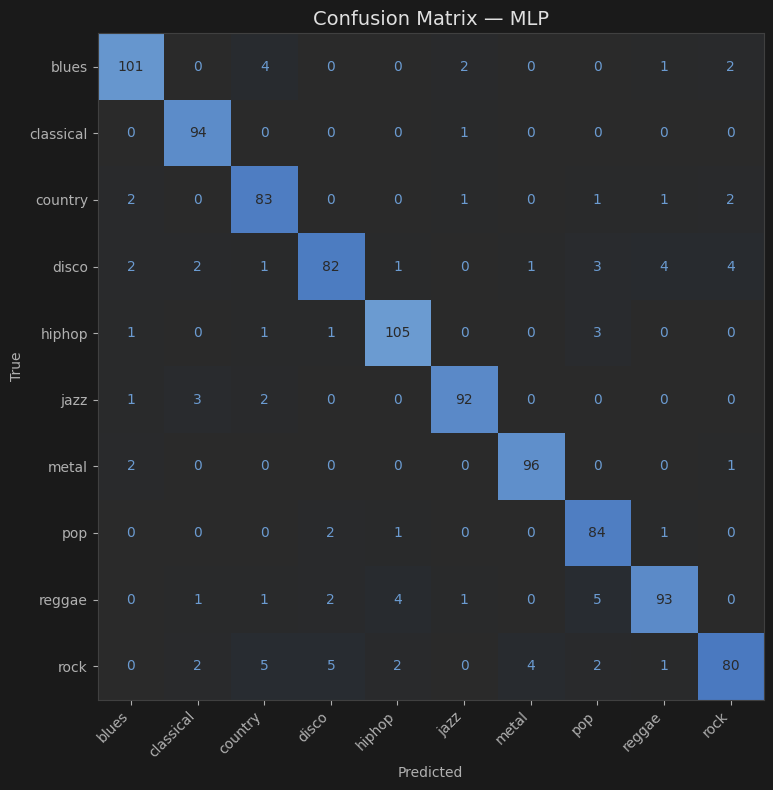

In [49]:
mlp_y_probs = mlp.predict(X_val_scaled)
mlp_y_pred = np.argmax(mlp_y_probs, axis=1)
print(f'MLP Accuracy: {mlp_history.history['accuracy'][-1]:.2%}')
styled_stats(y_val, mlp_y_pred, le, title='MLP')

### Best SVM
The support vector machine was the best model, so we explore that further here.

In [59]:
svc_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf'))
])

svc_param_grid = {
    'clf__C': [1, 10, 15, 50, 100],
    'clf__gamma': ['scale', 'auto'],
    'clf__class_weight': [None, 'balanced']
}

svc_grid = GridSearchCV(svc_pipe, svc_param_grid, cv=5, refit=True, verbose=2)
svc_grid.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END .clf__C=1, clf__class_weight=None, clf__gamma=scale; total time=   0.7s
[CV] END .clf__C=1, clf__class_weight=None, clf__gamma=scale; total time=   0.7s
[CV] END .clf__C=1, clf__class_weight=None, clf__gamma=scale; total time=   0.7s
[CV] END .clf__C=1, clf__class_weight=None, clf__gamma=scale; total time=   0.7s
[CV] END .clf__C=1, clf__class_weight=None, clf__gamma=scale; total time=   0.7s
[CV] END ..clf__C=1, clf__class_weight=None, clf__gamma=auto; total time=   0.6s
[CV] END ..clf__C=1, clf__class_weight=None, clf__gamma=auto; total time=   0.7s
[CV] END ..clf__C=1, clf__class_weight=None, clf__gamma=auto; total time=   0.7s
[CV] END ..clf__C=1, clf__class_weight=None, clf__gamma=auto; total time=   0.7s
[CV] END ..clf__C=1, clf__class_weight=None, clf__gamma=auto; total time=   0.7s
[CV] END clf__C=1, clf__class_weight=balanced, clf__gamma=scale; total time=   0.7s
[CV] END clf__C=1, clf__class_weight=balance

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...clf', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [1, 10, ...], 'clf__class_weight': [None, 'balanced'], 'clf__gamma': ['scale', 'auto']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

Best parameters: {'clf__C': 15, 'clf__class_weight': None, 'clf__gamma': 'scale'}
Accuracy: 0.92


,precision,recall,f1-score,support
blues,0.906780,0.972727,0.938596,110.000000
classical,0.877358,0.978947,0.925373,95.000000
country,0.857143,0.866667,0.861878,90.000000
disco,0.917526,0.890000,0.903553,100.000000
hiphop,0.938053,0.954955,0.946429,111.000000
jazz,0.928571,0.928571,0.928571,98.000000
metal,0.960000,0.969697,0.964824,99.000000
pop,0.943182,0.943182,0.943182,88.000000
reggae,0.951456,0.915888,0.933333,107.000000
rock,0.941176,0.792079,0.860215,101.000000


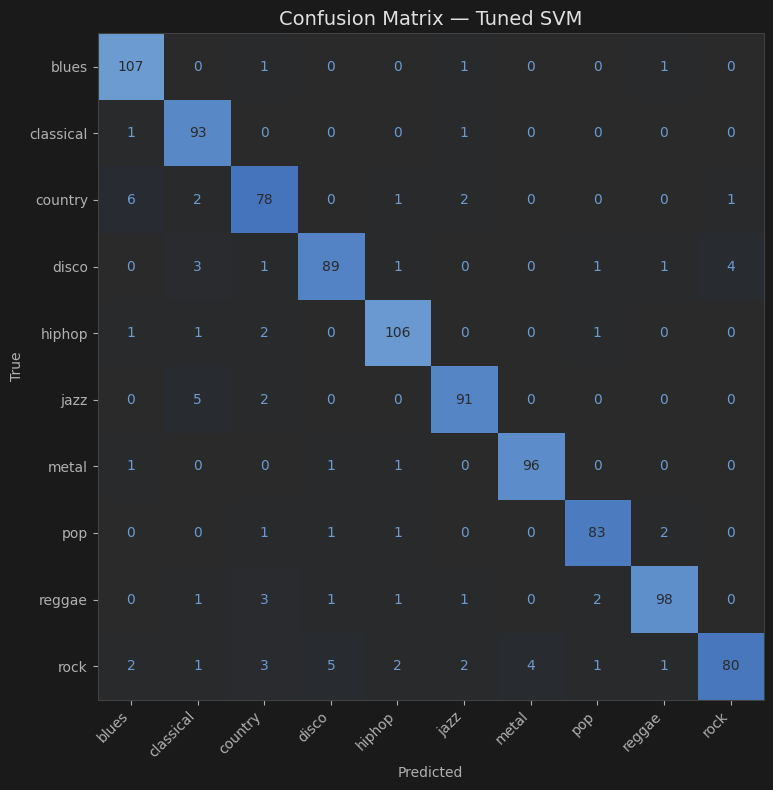

In [60]:
print(f'Best parameters: {svc_grid.best_params_}')
print(f'Accuracy: {svc_grid.score(X_val, y_val):.2f}')

svc_pred = svc_grid.predict(X_val)
styled_stats(y_val, svc_pred, le, title='Tuned SVM')

## Test on New Audio Files
Since the model was trained on 3 second segments, we should be conducting inference on 3 second segments. This prediction highly depends on the location of the segment. To smooth this variance out, we run inference on multiple 3 second samples from a controllable fraction of the song. Majority vote is then used for the final classification.

In [68]:
def _features_from_segment(y, sr):
    """Compute one feature dict from a single audio segment (e.g. 3 seconds)."""
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
    # RMS
    rms = librosa.feature.rms(y=y)
    # Spectral Centroid
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)
    # Spectral Bandwidth
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    # Rolloff
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    # Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y)
    # Harmony and Percussive
    harmony, perceptr = librosa.effects.hpss(y)
    # Tempo
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    # MFCCs (20 coefficients)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

    # 3. Aggregate Features (Mean and Variance)
    # The dataframe must match the order and naming convention of GTZAN
    features = {
        'chroma_stft_mean': np.mean(chroma_stft),
        'chroma_stft_var': np.var(chroma_stft),
        'rms_mean': np.mean(rms),
        'rms_var': np.var(rms),
        'spectral_centroid_mean': np.mean(spec_cent),
        'spectral_centroid_var': np.var(spec_cent),
        'spectral_bandwidth_mean': np.mean(spec_bw),
        'spectral_bandwidth_var': np.var(spec_bw),
        'rolloff_mean': np.mean(rolloff),
        'rolloff_var': np.var(rolloff),
        'zero_crossing_rate_mean': np.mean(zcr),
        'zero_crossing_rate_var': np.var(zcr),
        'harmony_mean': np.mean(harmony),
        'harmony_var': np.var(harmony),
        'perceptr_mean': np.mean(perceptr),
        'perceptr_var': np.var(perceptr),
        'tempo': float(np.atleast_1d(tempo).flat[0]),
    }

    # Add MFCCs 1-20 (Mean and Variance)
    for i in range(1, 21):
        features[f'mfcc{i}_mean'] = np.mean(mfccs[i-1])
        features[f'mfcc{i}_var'] = np.var(mfccs[i-1])

    return features


def extract_features(file_path, portion=1.0, segment_duration_sec=3):
    """Load a portion of the song's duration, split into whole 3s segments (round down), return one feature dict per segment."""
    total_duration = librosa.get_duration(path=file_path)
    duration_to_use = total_duration * portion
    num_segments = int(duration_to_use // segment_duration_sec)
    if num_segments == 0:
        return []
    load_duration = num_segments * segment_duration_sec
    y, sr = librosa.load(file_path, mono=True, duration=load_duration)
    segment_samples = segment_duration_sec * sr

    feature_list = []
    for i in range(num_segments):
        start = i * segment_samples
        end = start + segment_samples
        if end > len(y):
            break
        y_seg = y[start:end]
        feature_list.append(_features_from_segment(y_seg, sr))

    return feature_list


def classify_song(features_output, model, le):
    """Predict per segment, majority vote; return (genre_str, predictions_array)."""
    df = pd.DataFrame(features_output) if not isinstance(features_output, pd.DataFrame) else features_output
    if len(df) == 0:
        return None, np.array([])
    predictions = model.predict(df)
    counts = {}
    for p in predictions:
        counts[p] = counts.get(p, 0) + 1
    majority_label = max(counts, key=counts.get)
    genre_str = le.inverse_transform([majority_label])[0]
    return genre_str, predictions

In [71]:
test_songs_dir = 'data/test_songs'
audio_extensions = {'.wav', '.mp3', '.ogg', '.flac', '.m4a'}
audio_files = sorted([
    f for f in os.listdir(test_songs_dir)
    if os.path.splitext(f)[1].lower() in audio_extensions
])

for filename in audio_files:
    file_path = os.path.join(test_songs_dir, filename)
    feature_list = extract_features(file_path, portion=0.25)
    prediction_genre, predictions = classify_song(feature_list, svc_grid, le)
    segment_genres = le.inverse_transform(predictions) if len(predictions) > 0 else np.array([])
    print(f'--- {filename} ---')
    print(f'Prediction: {prediction_genre} (majority over {len(predictions)} segments)\n')

--- Classical__Fur_Elise.wav ---
Prediction: classical (majority over 15 segments)

--- Country__Tennessee_Whiskey.wav ---
Prediction: reggae (majority over 24 segments)

--- Jazz__Kathys_Waltz.mp3 ---
Prediction: jazz (majority over 23 segments)

--- Metal__Enter_Sandman.mp3 ---
Prediction: metal (majority over 27 segments)

--- Reggae__Could_You_Be_Loved.mp3 ---
Prediction: disco (majority over 19 segments)

--- Rock__Sabotage.mp3 ---
Prediction: rock (majority over 14 segments)

